In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

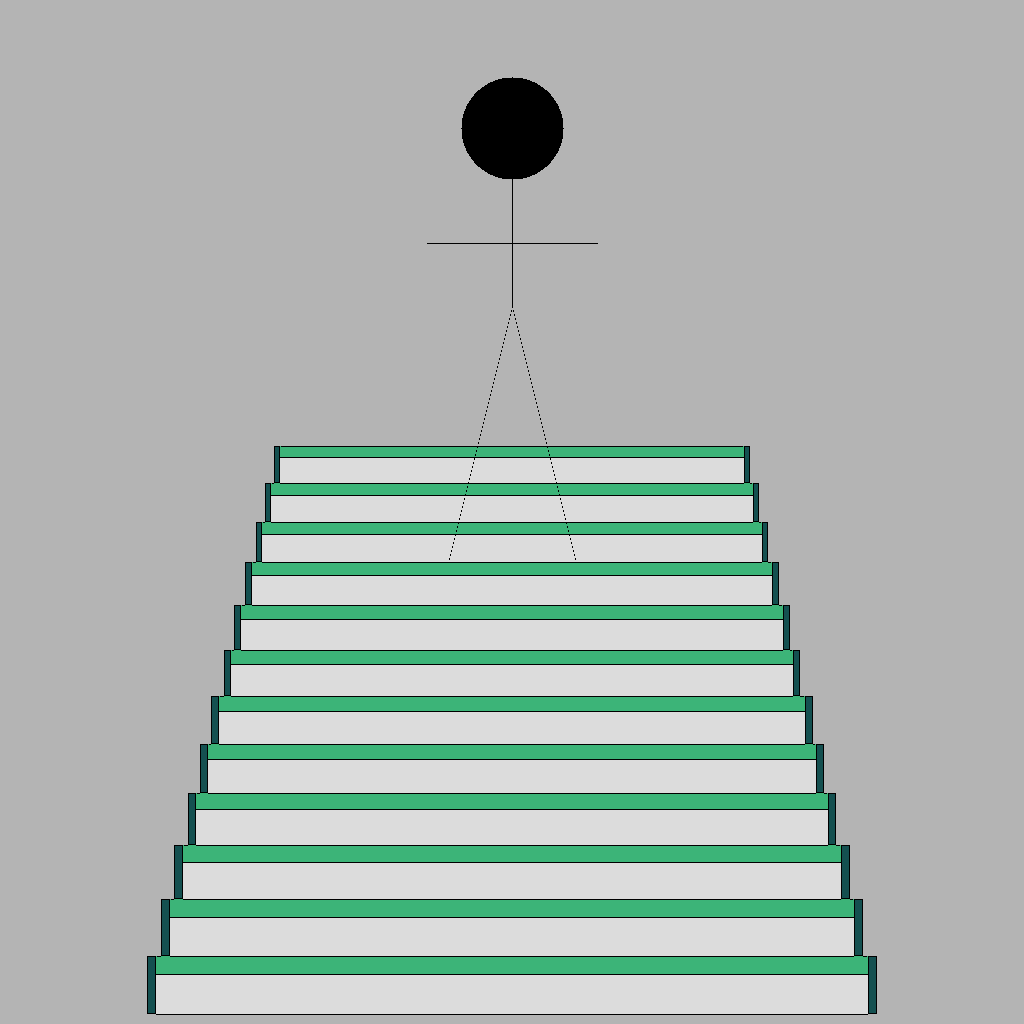

In [2]:
"""
謝謝 (((o(*ﾟ▽ﾟ*)o)))
"""
def mirror(a):
  return a|a[:,::-1]

def detect_edge(a):
    a = np.float32(a.sum(axis=-1))
    r = np.zeros(a.shape, dtype=bool)
    b = (a[1:-1, 2:] + a[1:-1, :-2] + a[2:, 1:-1] + a[:-2, 1:-1]) / 4
    r[1:-1, 1:-1] = a[1:-1, 1:-1] < b - 5  
    return r

size = 1024
img = np.ones((size, size, 3), dtype=np.uint8) * 180 

y, x = np.indices((size, size))

def create_stair(num_steps=12):

    # 透視參數
    vp_x = size // 2  # 消失點 x
    vp_y = -size // 2  # 消失點 y

    # 樓梯參數
    base_width = size * 0.7  # 底部寬度
    base_tread_depth = 40  # 水平深度
    base_riser_height = 20  # 垂直高度
    side_thickness = 10  # 側面厚度

    current_y = size - 10

    # 樓梯顏色
    top_color = np.array([220, 220, 220], dtype=np.uint8)  
    front_color = np.array([60, 180, 120], dtype=np.uint8)  
    side_color = np.array([20, 80, 80], dtype=np.uint8)  

    for i in range(num_steps):
        dist = (current_y - vp_y) / (size - vp_y)
        width = int(base_width * dist)
        tread = int(base_tread_depth * dist)
        riser = int(base_riser_height * dist)
        side_thick = int(side_thickness * dist)

        # 左右邊 x 位置
        left_x = vp_x - width // 2
        right_x = vp_x + width // 2

        # 水平頂面
        top_y_end = current_y
        top_y_start = top_y_end - tread
        top_mask = (y >= top_y_start) & (y < top_y_end) & \
                   (x >= left_x) & (x < right_x)
        img[top_mask] = top_color

        # 垂直面
        front_y_end = top_y_start
        front_y_start = front_y_end - riser
        front_mask = (y >= front_y_start) & (y < front_y_end) & \
                     (x >= left_x) & (x < right_x)
        img[front_mask] = front_color

        # 右側面
        side_right_mask = (y >= front_y_start) & (y < top_y_end) & \
                          (x >= right_x) & (x < right_x + side_thick)
        img[side_right_mask] = side_color

        # 左側面
        side_left_mask = (y >= front_y_start) & (y < top_y_end) & \
                         (x >= left_x - side_thick) & (x < left_x)
        img[side_left_mask] = side_color

        current_y = front_y_start

    edge_mask = detect_edge(img)
    img[edge_mask] = [0, 0, 0]

    return img

def create_human(img, size=512):
    # 頭部
    head_center_x = size
    head_center_y = size // 4
    head_radius = size // 10
    head_mask = (x - head_center_x)**2 + (y - head_center_y)**2 <= head_radius**2
    img[head_mask] = [0, 0, 0] 
    
    # 身體
    body_start_y = head_center_y + head_radius
    body_end_y = size // 2 + head_radius
    body_mask = (x == head_center_x) & (y >= body_start_y) & (y <= body_end_y)
    img[body_mask] = [0, 0, 0]
    
    # 手
    arm_y = (body_start_y + body_end_y) // 2
    arm_length = size // 6
    arm_left_mask = (y == arm_y) & (x >= head_center_x - arm_length) & (x < head_center_x)
    arm_right_mask = (y == arm_y) & (x > head_center_x) & (x <= head_center_x + arm_length)
    img[arm_left_mask] = [0, 0, 0]
    img[arm_right_mask] = [0, 0, 0]
    
    # 腿
    leg_start_y = body_end_y
    leg_end_y = size+50
    leg_length_x = size // 8
    
    # 左腿
    m_left = (leg_end_y - leg_start_y) / (-leg_length_x)
    leg_left_mask = np.abs((y - leg_start_y) - m_left * (x - head_center_x)) < 1
    leg_left_mask &= (x >= head_center_x - leg_length_x) & (x <= head_center_x)
    leg_left_mask &= (y >= leg_start_y) & (y <= leg_end_y)
    
    # 右腿
    m_right = (leg_end_y - leg_start_y) / leg_length_x
    leg_right_mask = np.abs((y - leg_start_y) - m_right * (x - head_center_x)) < 1
    leg_right_mask &= (x >= head_center_x) & (x <= head_center_x + leg_length_x)
    leg_right_mask &= (y >= leg_start_y) & (y <= leg_end_y)
    
    img[leg_left_mask] = [0, 0, 0]
    img[leg_right_mask] = [0, 0, 0]
    
    return img

# 可以調整 num_steps 來改變階梯數喔
stair_img = create_stair()
result = create_human(stair_img)

pil_img = Image.fromarray(result)
pil_img.show()
pil_img